# Sandbox to experiment with Pipelines

Using "modern" sklearn code as described on youtube [here](https://www.youtube.com/watch?v=lhMqqauXtW0)

In [ ]:
from eccore.ipython import nb_setup, pandas_nrows_ncols
nb_setup()

Set autoreload mode


In [ ]:
import re

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler

from myquantlab.core import load_test_df


# Reminder Pipeline mechanics

In [ ]:
df = load_test_df()
df.head(3)

,Open,High,Low,Close,Volume
dt,,,,,
2018-10-22,2759.02,2779.27,2747.27,2754.48,26562
2018-10-23,2753.11,2755.36,2690.69,2743.45,38777
2018-10-24,2744.83,2748.58,2651.23,2672.80,41777


In [ ]:
pipe = Pipeline([
    ('scaled', StandardScaler())
])

pipe.fit(df)

Pipeline(steps=[('scaled', StandardScaler())])

In [ ]:
display(pipe.feature_names_in_)
display(pipe.get_feature_names_out())

array(['Open', 'High', 'Low', 'Close', 'Volume'], dtype=object)

array(['Open', 'High', 'Low', 'Close', 'Volume'], dtype=object)

In [ ]:
pd.DataFrame(pipe.transform(df), columns=pipe.get_feature_names_out()).head(3)

,Open,High,Low,Close,Volume
0,0.862172,0.907814,0.929603,0.807820,0.002038
1,0.802435,0.647470,0.390629,0.696388,0.870961
2,0.718743,0.573646,0.014738,-0.017366,1.084369


In [ ]:
pipe = ColumnTransformer([
    ('scaled', StandardScaler(), ['Open', 'Close']),
    ('minmax', MinMaxScaler(), ['Volume'])
])

pd.DataFrame(data=pipe.fit_transform(df), columns=pipe.get_feature_names_out()).head(3)

,scaled__Open,scaled__Close,minmax__Volume
0,0.862172,0.807820,0.338889
1,0.802435,0.696388,0.551631
2,0.718743,-0.017366,0.603880


## Create custom transformers for feature engineering

- return per bar
- std on a window (5, 20, 60, 240 bars)
- MA on a window (5, 20, 60, 240 bars)
- EDA on a window (5, 20, 60, 240 bars)
- Information on the datatime (day of week, hour of day, opening hour, closing hour, etc.)

Base class that includes all common mechanics, including the column name handling

In [ ]:
class MyBaseTransformer(BaseEstimator, TransformerMixin):
    """Base class for my custom transformers"""
    def __init__(self):
        self.input_features_ = None
        self.output_features_ = None
        self.postfix = "transformed"

    def fit(self, X, y=None):
        if hasattr(X, 'columns'):
            self.input_features_ = X.columns.tolist()
        else:
            self.input_features_ = [f'f_{i}' for i in range(X.shape[1])]
        self.output_features_ = [f"{feat}_{self.postfix}" for feat in self.input_features_]
        return self

    def transform(self, X) -> np.ndarray:
        X = X.copy()
        return X.values

    def get_feature_names_out(self, input_features=None) -> list[str]|None:
        if input_features is not None:
            return [f"{feat}_{self.postfix}" for feat in input_features]
        else:
            return self.output_features_

In [ ]:
pipe = Pipeline([
    ('base-transformer', MyBaseTransformer())
])

pd.DataFrame(data=pipe.fit_transform(df), columns=pipe.get_feature_names_out()).head(5)

,Open_transformed,High_transformed,Low_transformed,Close_transformed,Volume_transformed
0,2759.02,2779.27,2747.27,2754.48,26562.0
1,2753.11,2755.36,2690.69,2743.45,38777.0
2,2744.83,2748.58,2651.23,2672.80,41777.0
3,2670.80,2722.90,2657.93,2680.71,39034.0
4,2675.59,2692.34,2627.59,2663.57,61436.0


In [ ]:
pipe = ColumnTransformer([
    ('base-transformer', MyBaseTransformer(), ['Open', 'Close'])
])

pd.DataFrame(data=pipe.fit_transform(df), columns=pipe.get_feature_names_out()).head(5)

,base-transformer__Open_transformed,base-transformer__Close_transformed
0,2759.02,2754.48
1,2753.11,2743.45
2,2744.83,2672.80
3,2670.80,2680.71
4,2675.59,2663.57


In [ ]:
class ReturnTransformer(MyBaseTransformer):
    def __init__(self, periods=1) -> None:
        super().__init__()
        self.periods = periods
        self.postfix = f"ret{self.periods}"
        self.nickname = f"return{self.periods}"

    def transform(self, X) -> np.ndarray:
        """percentage change with previous bar, fist bar is 0"""
        X = X.copy()
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        return X.pct_change(periods=self.periods).fillna(0.0).values

In [ ]:
pipe = ColumnTransformer([
    ('r', ReturnTransformer(), ['Open', 'Close'])
])
pd.DataFrame(pipe.fit_transform(df), columns=pipe.get_feature_names_out()).head(5)

,r__Open_ret1,r__Close_ret1
0,0.000000,0.000000
1,-0.002142,-0.004004
2,-0.003008,-0.025752
3,-0.026971,0.002959
4,0.001793,-0.006394


In [ ]:
class StdTransformer(MyBaseTransformer):
    def __init__(self, window:int=5) -> None:
        super().__init__()
        self.window = window
        self.postfix = f"std{self.window}"
        self.nickname = f"std{self.window}"

    def transform(self, X) -> np.ndarray:
        X = X.copy()
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        return X.rolling(window=self.window, min_periods=1).std().values

In [ ]:
pipe = ColumnTransformer([
    ('returns', StdTransformer(3), ['Open', 'Close'])
])
pd.DataFrame(data=pipe.fit_transform(df), columns=pipe.get_feature_names_out()).head(5)


,returns__Open_std3,returns__Close_std3
0,NaN,NaN
1,4.179001,7.799388
2,7.127910,44.318367
3,45.320958,38.708953
4,41.427774,8.578467


In [ ]:
pipe = ColumnTransformer([
    ('thru', 'passthrough', ['Open', 'High', 'Low', 'Close', 'Volume']),
    ('r', ReturnTransformer(), ['Close']),
    ('std', StdTransformer(5), ['Close'])
], )


pd.DataFrame(
    pipe.fit_transform(df), 
    columns=pipe.get_feature_names_out()
    ).head(5)

,thru__Open,thru__High,thru__Low,thru__Close,thru__Volume,r__Close_ret1,std__Close_std5
0,2759.02,2779.27,2747.27,2754.48,26562.0,0.000000,NaN
1,2753.11,2755.36,2690.69,2743.45,38777.0,-0.004004,7.799388
2,2744.83,2748.58,2651.23,2672.80,41777.0,-0.025752,44.318367
3,2670.80,2722.90,2657.93,2680.71,39034.0,0.002959,42.057098
4,2675.59,2692.34,2627.59,2663.57,61436.0,-0.006394,42.573471


In [ ]:
class MATransformer(MyBaseTransformer):
    def __init__(self, window:int=5) -> None:
        super().__init__()
        self.window = window
        self.postfix = f"MA{self.window}"
        self.nickname = f"ma{self.window}"

    def transform(self, X) -> np.ndarray:
        X = X.copy()
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        return X.rolling(window=self.window, min_periods=1).mean().values

class EMATransformer(MyBaseTransformer):
    def __init__(self, window:int=5) -> None:
        super().__init__()
        self.window = window
        self.postfix = f"EMA{self.window}"
        self.nickname = f"ema{self.window}"

    def transform(self, X) -> np.ndarray:
        X = X.copy()
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        return X.ewm(span=self.window).mean().values

In [ ]:
pipe = ColumnTransformer([
    ('thru', 'passthrough', ['Open', 'High', 'Low', 'Close', 'Volume']),
    ('ma', MATransformer(3), ['Open', 'Close']),
    ('ema', EMATransformer(3), ['Open', 'Close'])
])
pd.DataFrame(data=pipe.fit_transform(df), columns=pipe.get_feature_names_out()).head(5)


,thru__Open,thru__High,thru__Low,thru__Close,thru__Volume,ma__Open_MA3,ma__Close_MA3,ema__Open_EMA3,ema__Close_EMA3
0,2759.02,2779.27,2747.27,2754.48,26562.0,2759.020000,2754.480000,2759.020000,2754.480000
1,2753.11,2755.36,2690.69,2743.45,38777.0,2756.065000,2748.965000,2755.080000,2747.126667
2,2744.83,2748.58,2651.23,2672.80,41777.0,2752.320000,2723.576667,2749.222857,2704.654286
3,2670.80,2722.90,2657.93,2680.71,39034.0,2722.913333,2698.986667,2707.397333,2691.884000
4,2675.59,2692.34,2627.59,2663.57,61436.0,2697.073333,2672.360000,2690.980645,2677.270323


In [ ]:
pipe = ColumnTransformer([
    ('thru', 'passthrough', ['Open', 'High', 'Low', 'Close', 'Volume']),
    ('r', ReturnTransformer(1), ['Close']),
    ('std', StdTransformer(5), ['Close']),
    ('ema5', EMATransformer(5), ['Close']),
    ('ema20', EMATransformer(20), ['Close']),
    ('ema60', EMATransformer(60), ['Close'])
])
df_proc = pd.DataFrame(data=pipe.fit_transform(df), columns=pipe.get_feature_names_out())
df_proc.head(5)

,thru__Open,thru__High,thru__Low,thru__Close,thru__Volume,r__Close_ret1,std__Close_std5,ema5__Close_EMA5,ema20__Close_EMA20,ema60__Close_EMA60
0,2759.02,2779.27,2747.27,2754.48,26562.0,0.000000,NaN,2754.480000,2754.480000,2754.480000
1,2753.11,2755.36,2690.69,2743.45,38777.0,-0.004004,7.799388,2747.862000,2748.689250,2748.873083
2,2744.83,2748.58,2651.23,2672.80,41777.0,-0.025752,44.318367,2712.306316,2720.823172,2722.665515
3,2670.80,2722.90,2657.93,2680.71,39034.0,0.002959,42.057098,2699.181692,2709.243120,2711.646464
4,2675.59,2692.34,2627.59,2663.57,61436.0,-0.006394,42.573471,2685.510853,2698.195181,2701.379651


In [ ]:
pipe.get_feature_names_out()

array(['thru__Open', 'thru__High', 'thru__Low', 'thru__Close',
       'thru__Volume', 'r__Close_ret1', 'std__Close_std5',
       'ema5__Close_EMA5', 'ema20__Close_EMA20', 'ema60__Close_EMA60'],
      dtype=object)

Rules to change the columns names:
- OHLCV with no trailing `_` back to original value
- OHLCV with `_` before and after, drop the before

In [ ]:
def simplify_colnames(cols)->list[str]:
    pat = re.compile(r"[\w\d\-]*_{2}(?P<end>\w*)")
    cols = [pat.match(c).group('end') for c in cols]
    return cols

simplify_colnames(pipe.get_feature_names_out())

['Open',
 'High',
 'Low',
 'Close',
 'Volume',
 'Close_ret1',
 'Close_std5',
 'Close_EMA5',
 'Close_EMA20',
 'Close_EMA60']

In [ ]:
df_proc = pd.DataFrame(data=pipe.fit_transform(df), columns=simplify_colnames(pipe.get_feature_names_out()))
df_proc.head(5)

,Open,High,Low,Close,Volume,Close_ret1,Close_std5,Close_EMA5,Close_EMA20,Close_EMA60
0,2759.02,2779.27,2747.27,2754.48,26562.0,0.000000,NaN,2754.480000,2754.480000,2754.480000
1,2753.11,2755.36,2690.69,2743.45,38777.0,-0.004004,7.799388,2747.862000,2748.689250,2748.873083
2,2744.83,2748.58,2651.23,2672.80,41777.0,-0.025752,44.318367,2712.306316,2720.823172,2722.665515
3,2670.80,2722.90,2657.93,2680.71,39034.0,0.002959,42.057098,2699.181692,2709.243120,2711.646464
4,2675.59,2692.34,2627.59,2663.57,61436.0,-0.006394,42.573471,2685.510853,2698.195181,2701.379651


In [ ]:
pipe_stats = FeatureUnion([
    ('thru', 'passthrough'),
    ('std', StdTransformer(5)),
    ('ema5', EMATransformer(5)),
    ('ema20', EMATransformer(20)),
    ('ema60', EMATransformer(60))
    ])

In [ ]:
pipe_return = Pipeline([
    ('calc_returns', ReturnTransformer(1)),
    ('stats_returns', pipe_stats),
])
pipe_return

Pipeline(steps=[('calc_returns', ReturnTransformer()),
                ('stats_returns',
                 FeatureUnion(transformer_list=[('thru', 'passthrough'),
                                                ('std', StdTransformer()),
                                                ('ema5', EMATransformer()),
                                                ('ema20',
                                                 EMATransformer(window=20)),
                                                ('ema60',
                                                 EMATransformer(window=60))]))])

In [ ]:
pipe_return.fit(df[['Close']])
display(pipe_return.get_feature_names_out().tolist())
display(simplify_colnames(pipe_return.get_feature_names_out()))

['thru__Close_ret1',
 'std__Close_ret1_std5',
 'ema5__Close_ret1_EMA5',
 'ema20__Close_ret1_EMA20',
 'ema60__Close_ret1_EMA60']

['Close_ret1',
 'Close_ret1_std5',
 'Close_ret1_EMA5',
 'Close_ret1_EMA20',
 'Close_ret1_EMA60']

In [ ]:
pipe_return.named_steps

{'calc_returns': ReturnTransformer(),
 'stats_returns': FeatureUnion(transformer_list=[('thru',
                                 FunctionTransformer(feature_names_out='one-to-one')),
                                ('std', StdTransformer()),
                                ('ema5', EMATransformer()),
                                ('ema20', EMATransformer(window=20)),
                                ('ema60', EMATransformer(window=60))])}

In [ ]:
pipe = ColumnTransformer([
    ('thru', 'passthrough', ['Open', 'High', 'Low', 'Close', 'Volume']),
    ('ret', pipe_return, ['Open','Close']),
])
pipe.fit(df)
pipe.get_feature_names_out()

array(['thru__Open', 'thru__High', 'thru__Low', 'thru__Close',
       'thru__Volume', 'ret__thru__Open_ret1', 'ret__thru__Close_ret1',
       'ret__std__Open_ret1_std5', 'ret__std__Close_ret1_std5',
       'ret__ema5__Open_ret1_EMA5', 'ret__ema5__Close_ret1_EMA5',
       'ret__ema20__Open_ret1_EMA20', 'ret__ema20__Close_ret1_EMA20',
       'ret__ema60__Open_ret1_EMA60', 'ret__ema60__Close_ret1_EMA60'],
      dtype=object)

In [ ]:
pipe.get_feature_names_out()

array(['thru__Open', 'thru__High', 'thru__Low', 'thru__Close',
       'thru__Volume', 'ret__thru__Open_ret1', 'ret__thru__Close_ret1',
       'ret__std__Open_ret1_std5', 'ret__std__Close_ret1_std5',
       'ret__ema5__Open_ret1_EMA5', 'ret__ema5__Close_ret1_EMA5',
       'ret__ema20__Open_ret1_EMA20', 'ret__ema20__Close_ret1_EMA20',
       'ret__ema60__Open_ret1_EMA60', 'ret__ema60__Close_ret1_EMA60'],
      dtype=object)

In [ ]:
df_proc = pd.DataFrame(data=pipe.fit_transform(df))
df_proc.columns = simplify_colnames(pipe.get_feature_names_out())
df_proc.index=df.index
df_proc.head(5)

,Open,High,Low,Close,Volume,Open_ret1,Close_ret1,Open_ret1_std5,Close_ret1_std5,Open_ret1_EMA5,Close_ret1_EMA5,Open_ret1_EMA20,Close_ret1_EMA20,Open_ret1_EMA60,Close_ret1_EMA60
dt,,,,,,,,,,,,,,,
2018-10-22,2759.02,2779.27,2747.27,2754.48,26562.0,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2018-10-23,2753.11,2755.36,2690.69,2743.45,38777.0,-0.002142,-0.004004,0.001515,0.002832,-0.001285,-0.002403,-0.001125,-0.002102,-0.001089,-0.002036
2018-10-24,2744.83,2748.58,2651.23,2672.80,41777.0,-0.003008,-0.025752,0.001548,0.013858,-0.002101,-0.013463,-0.001816,-0.010786,-0.001750,-0.010206
2018-10-25,2670.80,2722.90,2657.93,2680.71,39034.0,-0.026971,0.002959,0.012690,0.013019,-0.012432,-0.006641,-0.009078,-0.006818,-0.008374,-0.006748
2018-10-26,2675.59,2692.34,2627.59,2663.57,61436.0,0.001793,-0.006394,0.011836,0.011275,-0.006971,-0.006546,-0.006448,-0.006716,-0.006203,-0.006673


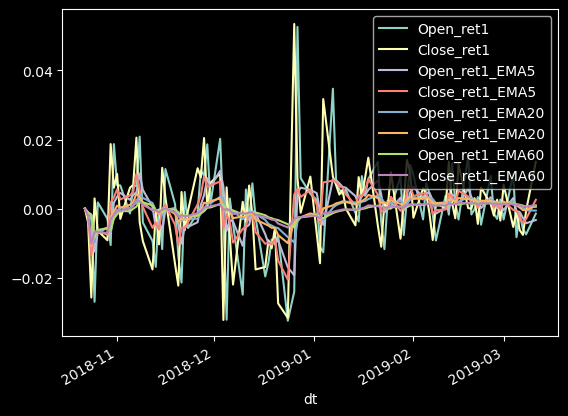

In [ ]:
df_proc.loc[:, [c for c in df_proc.columns if 'ret' in c and 'std' not in c]].plot();

Then we create a pipeline to calculate the returns on Close and apply the stats pipeline to the returns.

In [ ]:
pipe_returns = Pipeline([
    ('calc_returns', ReturnTransformer(1)),
    ('stats_returns', pipe_stats),
])
pipe_returns

Pipeline(steps=[('calc_returns', ReturnTransformer()),
                ('stats_returns',
                 FeatureUnion(transformer_list=[('thru',
                                                 FunctionTransformer(feature_names_out='one-to-one')),
                                                ('std', StdTransformer()),
                                                ('ema5', EMATransformer()),
                                                ('ema20',
                                                 EMATransformer(window=20)),
                                                ('ema60',
                                                 EMATransformer(window=60))]))])

This allows to create a dataset with the original OHLCV data, the returns on Close and statistics on the returns.

In [ ]:
pipe = ColumnTransformer([
    ('thru', 'passthrough', ['Open', 'High', 'Low', 'Close', 'Volume']),
    ('ret', pipe_returns, ['Close']),
])

pipe

ColumnTransformer(transformers=[('thru', 'passthrough',
                                 ['Open', 'High', 'Low', 'Close', 'Volume']),
                                ('ret',
                                 Pipeline(steps=[('calc_returns',
                                                  ReturnTransformer()),
                                                 ('stats_returns',
                                                  FeatureUnion(transformer_list=[('thru',
                                                                                  FunctionTransformer(feature_names_out='one-to-one')),
                                                                                 ('std',
                                                                                  StdTransformer()),
                                                                                 ('ema5',
                                                                                  EMATransformer()),
                                                                                 ('ema20',
                                                                                  EMATransformer(window=20)),
                                                                                 ('ema60',
                                                                                  EMATransformer(window=60))]))]),
                                 ['Close'])])

In [ ]:
df_proc = pd.DataFrame(
    data=pipe.fit_transform(df), 
    columns=pipe.get_feature_names_out(),
    index=df.index)
df_proc.head(5)

,thru__Open,thru__High,thru__Low,thru__Close,thru__Volume,ret__thru__Close_ret1,ret__std__Close_ret1_std5,ret__ema5__Close_ret1_EMA5,ret__ema20__Close_ret1_EMA20,ret__ema60__Close_ret1_EMA60
dt,,,,,,,,,,
2018-10-22,2759.02,2779.27,2747.27,2754.48,26562.0,0.000000,NaN,0.000000,0.000000,0.000000
2018-10-23,2753.11,2755.36,2690.69,2743.45,38777.0,-0.004004,0.002832,-0.002403,-0.002102,-0.002036
2018-10-24,2744.83,2748.58,2651.23,2672.80,41777.0,-0.025752,0.013858,-0.013463,-0.010786,-0.010206
2018-10-25,2670.80,2722.90,2657.93,2680.71,39034.0,0.002959,0.013019,-0.006641,-0.006818,-0.006748
2018-10-26,2675.59,2692.34,2627.59,2663.57,61436.0,-0.006394,0.011275,-0.006546,-0.006716,-0.006673


The pipeline generates a pretty long name for the features.

We can use `simplify_colnames` to simplify the names of the features.

In [ ]:
df_proc = pd.DataFrame(
    data=pipe.fit_transform(df), 
    columns=simplify_colnames(pipe.get_feature_names_out()),
    index=df.index)
df_proc.head(5)

,Open,High,Low,Close,Volume,Close_ret1,Close_ret1_std5,Close_ret1_EMA5,Close_ret1_EMA20,Close_ret1_EMA60
dt,,,,,,,,,,
2018-10-22,2759.02,2779.27,2747.27,2754.48,26562.0,0.000000,NaN,0.000000,0.000000,0.000000
2018-10-23,2753.11,2755.36,2690.69,2743.45,38777.0,-0.004004,0.002832,-0.002403,-0.002102,-0.002036
2018-10-24,2744.83,2748.58,2651.23,2672.80,41777.0,-0.025752,0.013858,-0.013463,-0.010786,-0.010206
2018-10-25,2670.80,2722.90,2657.93,2680.71,39034.0,0.002959,0.013019,-0.006641,-0.006818,-0.006748
2018-10-26,2675.59,2692.34,2627.59,2663.57,61436.0,-0.006394,0.011275,-0.006546,-0.006716,-0.006673


`dframe` performs this operation on the dataframe directly

In [ ]:
from myquantlab.pipeline import dframe
dframe(df, pipe).head(5)

,Open,High,Low,Close,Volume,Close_ret1,Close_ret1_std5,Close_ret1_EMA5,Close_ret1_EMA20,Close_ret1_EMA60
dt,,,,,,,,,,
2018-10-22,2759.02,2779.27,2747.27,2754.48,26562.0,0.000000,NaN,0.000000,0.000000,0.000000
2018-10-23,2753.11,2755.36,2690.69,2743.45,38777.0,-0.004004,0.002832,-0.002403,-0.002102,-0.002036
2018-10-24,2744.83,2748.58,2651.23,2672.80,41777.0,-0.025752,0.013858,-0.013463,-0.010786,-0.010206
2018-10-25,2670.80,2722.90,2657.93,2680.71,39034.0,0.002959,0.013019,-0.006641,-0.006818,-0.006748
2018-10-26,2675.59,2692.34,2627.59,2663.57,61436.0,-0.006394,0.011275,-0.006546,-0.006716,-0.006673


### Create a flexible pipeline to make a dataset from OHLCV data

input: OHLCV data
parameters: 
- feature creation:
    - `coi`: list of columns to apply the feature engineering on
    - `transforms`: list of transforms to apply on each selected column
- stats applied to new features
    - `stats`: list of stats to apply on new feature


In [ ]:
coi = ['Open', 'Close']
transforms = [ReturnTransformer(1),ReturnTransformer(10)]
stats = [EMATransformer(5), EMATransformer(20), EMATransformer(60), StdTransformer(5)]

In [ ]:
feature_stats_steps = [('thru', 'passthrough')]
for stat in stats:
    feature_stats_steps.append((stat.nickname, stat))
feature_stats = FeatureUnion(feature_stats_steps)
feature_stats.nickname = 'stats'

feature_stats

FeatureUnion(transformer_list=[('thru', 'passthrough'),
                               ('ema5', EMATransformer()),
                               ('ema20', EMATransformer(window=20)),
                               ('ema60', EMATransformer(window=60)),
                               ('std5', StdTransformer())])

In [ ]:
feature_engineering = [Pipeline([(t.nickname, t),(t.nickname+feature_stats.nickname, feature_stats)]) for t in transforms]
feature_engineering

[Pipeline(steps=[('return1', ReturnTransformer()),
                 ('return1stats',
                  FeatureUnion(transformer_list=[('thru', 'passthrough'),
                                                 ('ema5', EMATransformer()),
                                                 ('ema20',
                                                  EMATransformer(window=20)),
                                                 ('ema60',
                                                  EMATransformer(window=60)),
                                                 ('std5', StdTransformer())]))]),
 Pipeline(steps=[('return10', ReturnTransformer(periods=10)),
                 ('return10stats',
                  FeatureUnion(transformer_list=[('thru', 'passthrough'),
                                                 ('ema5', EMATransformer()),
                                                 ('ema20',
                                                  EMATransformer(window=20)),
                       

In [ ]:
feature_engineering[0].steps[0][0]

'return1'

In [ ]:
pipe_steps = [('thru', 'passthrough', ['Open', 'High', 'Low', 'Close', 'Volume'])]

for feat in feature_engineering:
    pipe_steps.append((feat.steps[0][0], feat, coi))

pipe = ColumnTransformer(pipe_steps)

pipe

ColumnTransformer(transformers=[('thru', 'passthrough',
                                 ['Open', 'High', 'Low', 'Close', 'Volume']),
                                ('return1',
                                 Pipeline(steps=[('return1',
                                                  ReturnTransformer()),
                                                 ('return1stats',
                                                  FeatureUnion(transformer_list=[('thru',
                                                                                  'passthrough'),
                                                                                 ('ema5',
                                                                                  EMATransformer()),
                                                                                 ('ema20',
                                                                                  EMATransformer(window=20)),
                                                                                 ('ema60',
                                                                                  EMATransformer(window=60)),
                                                                                 ('std5',
                                                                                  StdTransformer())]))]),
                                 ['Open', 'Close']),
                                ('return10',
                                 Pipeline(steps=[('return10',
                                                  ReturnTransformer(periods=10)),
                                                 ('return10stats',
                                                  FeatureUnion(transformer_list=[('thru',
                                                                                  'passthrough'),
                                                                                 ('ema5',
                                                                                  EMATransformer()),
                                                                                 ('ema20',
                                                                                  EMATransformer(window=20)),
                                                                                 ('ema60',
                                                                                  EMATransformer(window=60)),
                                                                                 ('std5',
                                                                                  StdTransformer())]))]),
                                 ['Open', 'Close'])])

In [ ]:
with pandas_nrows_ncols():
    display(dframe(df, pipe).head(5))

,Open,High,Low,Close,Volume,Open_ret1,Close_ret1,Open_ret1_EMA5,Close_ret1_EMA5,Open_ret1_EMA20,Close_ret1_EMA20,Open_ret1_EMA60,Close_ret1_EMA60,Open_ret1_std5,Close_ret1_std5,Open_ret10,Close_ret10,Open_ret10_EMA5,Close_ret10_EMA5,Open_ret10_EMA20,Close_ret10_EMA20,Open_ret10_EMA60,Close_ret10_EMA60,Open_ret10_std5,Close_ret10_std5
dt,,,,,,,,,,,,,,,,,,,,,,,,,
2018-10-22,2759.02,2779.27,2747.27,2754.48,26562.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
2018-10-23,2753.11,2755.36,2690.69,2743.45,38777.0,-0.002142,-0.004004,-0.001285,-0.002403,-0.001125,-0.002102,-0.001089,-0.002036,0.001515,0.002832,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-10-24,2744.83,2748.58,2651.23,2672.80,41777.0,-0.003008,-0.025752,-0.002101,-0.013463,-0.001816,-0.010786,-0.001750,-0.010206,0.001548,0.013858,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-10-25,2670.80,2722.90,2657.93,2680.71,39034.0,-0.026971,0.002959,-0.012432,-0.006641,-0.009078,-0.006818,-0.008374,-0.006748,0.012690,0.013019,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-10-26,2675.59,2692.34,2627.59,2663.57,61436.0,0.001793,-0.006394,-0.006971,-0.006546,-0.006448,-0.006716,-0.006203,-0.006673,0.011836,0.011275,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
